In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import joblib
import os
import json
from datetime import datetime


In [ ]:
df = pd.read_csv("/content/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.isna().sum().sum()

np.int64(0)

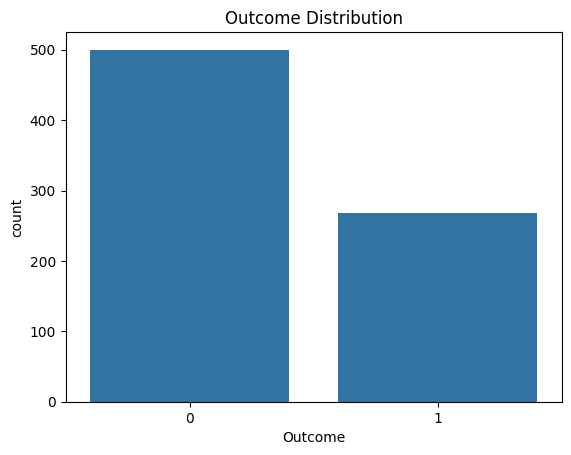

In [ ]:
sns.countplot(x="Outcome", data=df)
plt.title("Outcome Distribution")
plt.show()


In [ ]:
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]


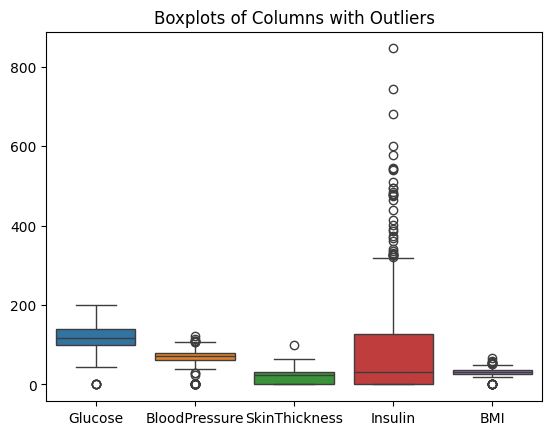

In [ ]:
sns.boxplot(data=df[cols_with_zeros])
plt.title("Boxplots of Columns with Outliers")
plt.show()


In [ ]:
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)


In [ ]:
TARGET_COL = "Outcome"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]


In [ ]:
# Numeric columns
num_cols = X.columns.tolist()

# Imputer: replace NaN with mean
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Full preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols)
])


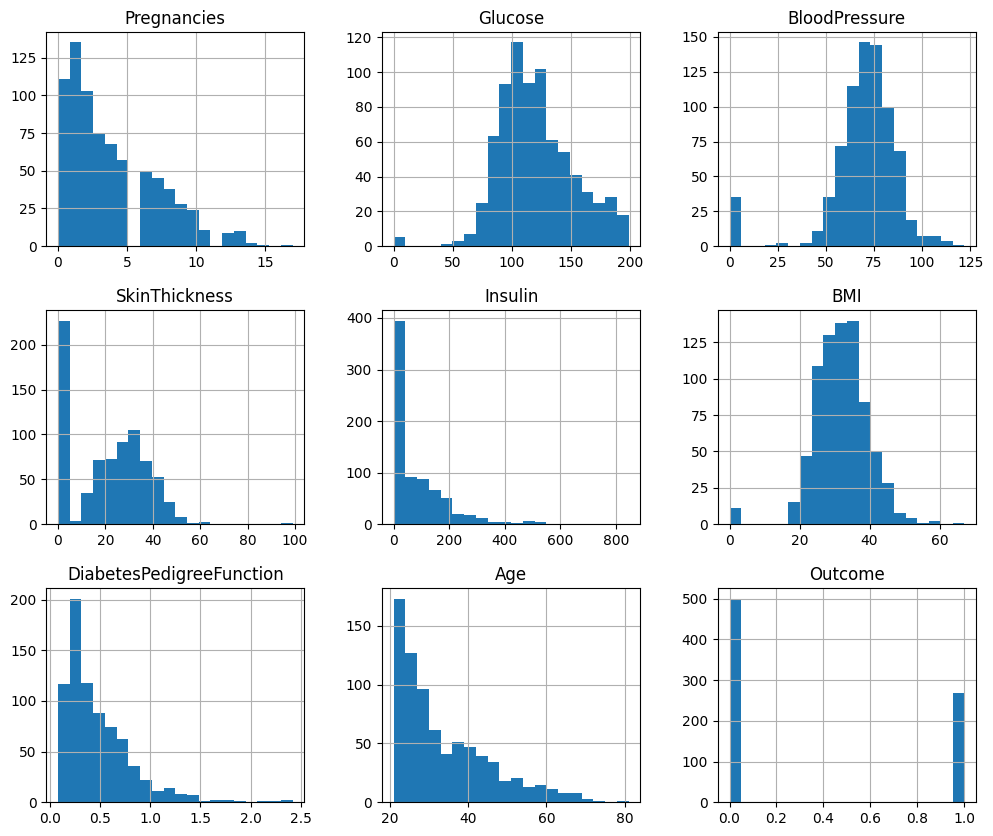

In [ ]:
df.hist(figsize=(12,10), bins=20)
plt.show()


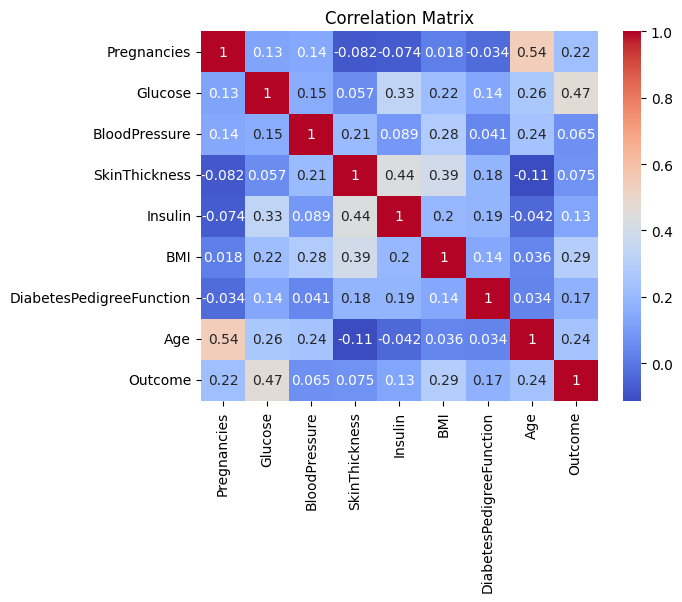

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42, stratify=y
)


Logistic Regression Pipeline

In [ ]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])


Decision Tree Pipeline

In [ ]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])


In [ ]:
# Logistic Regression
lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
# Decision Tree
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
# Logistic Regression
y_pred_lr = lr_pipeline.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7445887445887446
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.52      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.74       231



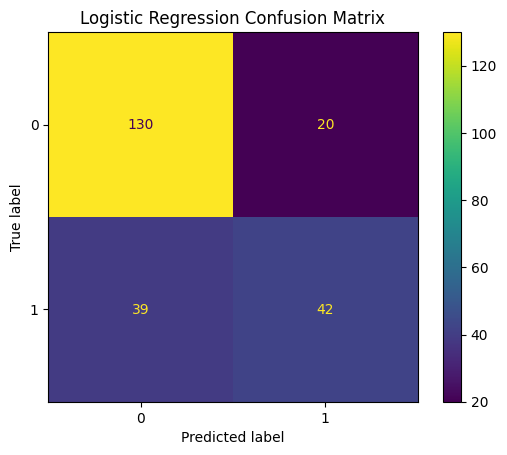

In [ ]:
ConfusionMatrixDisplay.from_estimator(lr_pipeline, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# Decision Tree
y_pred_dt = dt_pipeline.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7619047619047619
              precision    recall  f1-score   support

           0       0.78      0.87      0.83       150
           1       0.70      0.56      0.62        81

    accuracy                           0.76       231
   macro avg       0.74      0.71      0.72       231
weighted avg       0.76      0.76      0.75       231



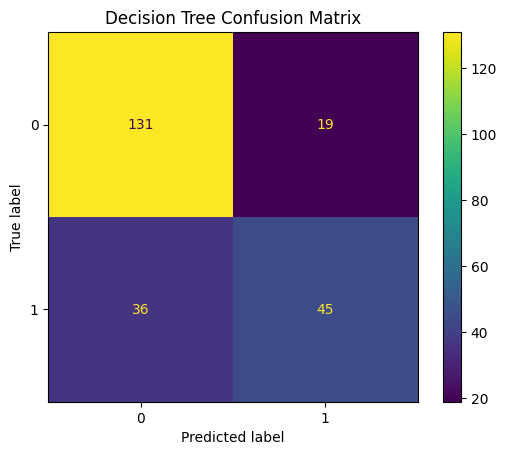

In [ ]:
ConfusionMatrixDisplay.from_estimator(dt_pipeline, X_test, y_test)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [ ]:
BUNDLE_DIR = "model_bundle"
os.makedirs(BUNDLE_DIR, exist_ok=True)

# Save pipelines
joblib.dump(lr_pipeline, os.path.join(BUNDLE_DIR, "logistic_model.joblib"))
joblib.dump(dt_pipeline, os.path.join(BUNDLE_DIR, "decision_tree_model.joblib"))

# Save schema
schema = {
    "required_columns": X.columns.tolist(),
    "numeric_columns": num_cols,
    "target": TARGET_COL
}
with open(os.path.join(BUNDLE_DIR, "schema.json"), "w") as f:
    json.dump(schema, f, indent=2)

# Save metadata
metadata = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "model_type": "LogisticRegression + DecisionTree",
    "metrics": {
        "logistic_accuracy": float(accuracy_score(y_test, y_pred_lr)),
        "decision_tree_accuracy": float(accuracy_score(y_test, y_pred_dt))
    },
    "author": "your_name"
}
with open(os.path.join(BUNDLE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)


/tmp/ipython-input-222986218.py:19: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",


In [ ]:
example_inputs = X_test.head(10).copy()
golden_outputs_lr = lr_pipeline.predict(example_inputs)
golden_outputs_dt = dt_pipeline.predict(example_inputs)

example_inputs.to_json(os.path.join(BUNDLE_DIR, "example_inputs.json"), orient="records")
with open(os.path.join(BUNDLE_DIR, "golden_outputs.json"), "w") as f:
    json.dump({
        "logistic_predictions": golden_outputs_lr.tolist(),
        "tree_predictions": golden_outputs_dt.tolist()
    }, f, indent=2)


In [ ]:
# Load models back
lr_reload = joblib.load(os.path.join(BUNDLE_DIR, "logistic_model.joblib"))
dt_reload = joblib.load(os.path.join(BUNDLE_DIR, "decision_tree_model.joblib"))

# Predict on example_inputs
assert np.allclose(lr_reload.predict(example_inputs), golden_outputs_lr)
assert np.allclose(dt_reload.predict(example_inputs), golden_outputs_dt)

print(" Reload validation PASSED: predictions match")


 Reload validation PASSED: predictions match


In [ ]:
!ls -R model_bundle


model_bundle:
decision_tree_model.joblib  golden_outputs.json    metadata.json
example_inputs.json	    logistic_model.joblib  schema.json
